Step 1: Import Libraries


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load Dataset

In [15]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df = df.drop('Cabin', axis=1)


Step 3: Dataset Information

In [17]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB
None


In [18]:
print(df.shape)


(891, 11)


In [19]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


Step 4: Check Missing Values

In [20]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64


Step 5: Handle Missing Values

In [21]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Step 6: Statistical Summary

In [23]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


Step 7: Survival Count

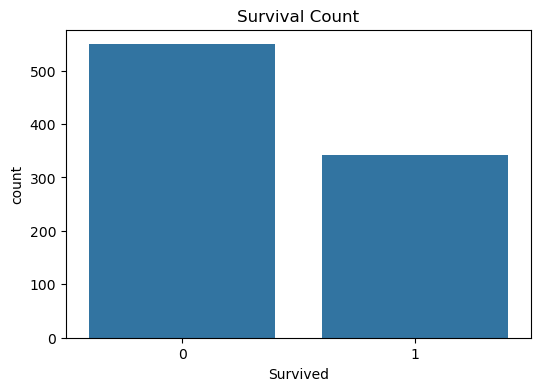

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

Step 8: Gender Analysis

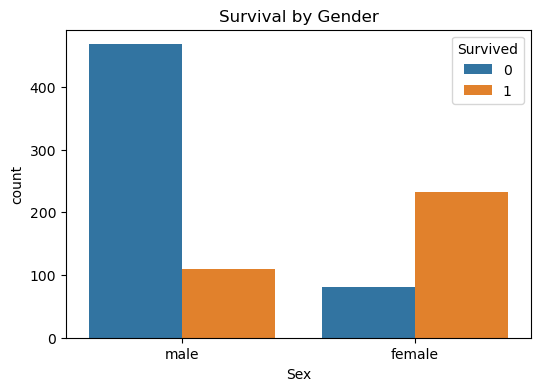

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

Step 9: Passenger Class Analysis

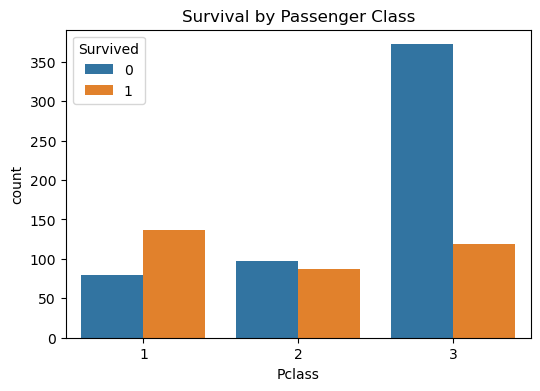

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

Step 10: Age Distribution

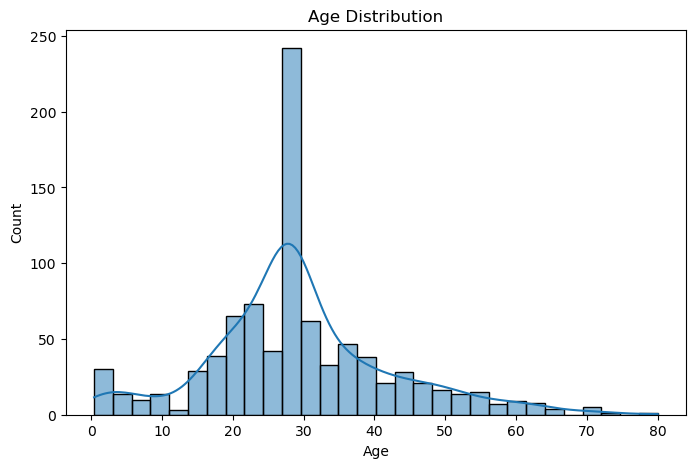

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

Step 11: Fare Distribution

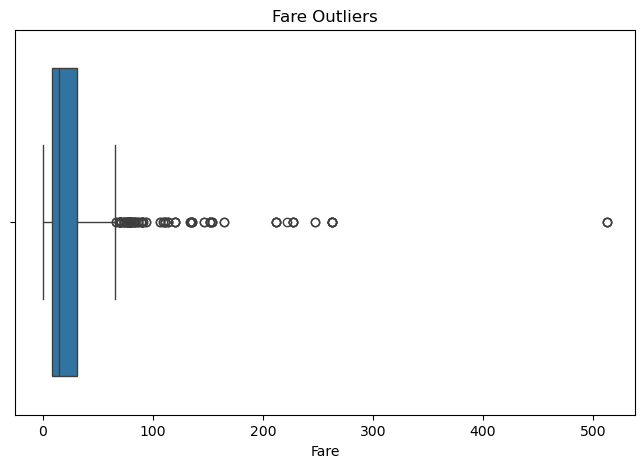

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Fare Outliers')
plt.show()

Step 12: Outlier Detection and Correction

In [34]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

print(outliers.shape)
outliers.head()

(116, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,28.0,1,0,PC 17569,146.5208,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,C


Outlier Correction Using Capping

In [35]:
df['Fare'] = np.where(df['Fare'] > upper_bound, upper_bound, df['Fare'])
df['Fare'] = np.where(df['Fare'] < lower_bound, lower_bound, df['Fare'])

Step 13: Correlation Analysis

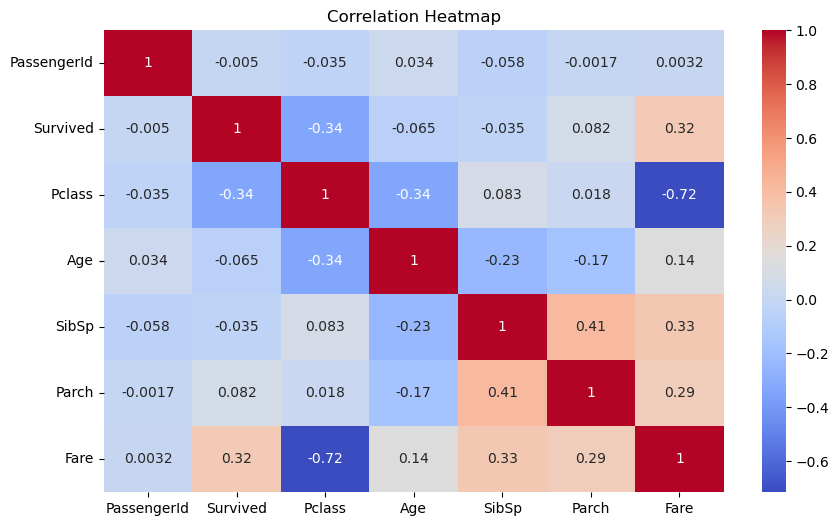

In [37]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Step 14: Survival Rate by Age Group

C:\Users\Sahil\AppData\Local\Temp\ipykernel_14488\2272573308.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_age = df.groupby('AgeGroup')['Survived'].mean()


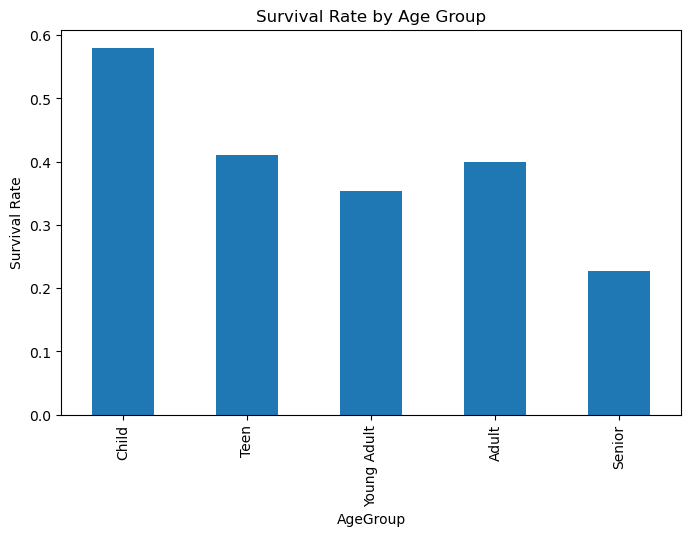

In [39]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,19,35,60,100], labels=['Child','Teen','Young Adult','Adult','Senior'])

survival_age = df.groupby('AgeGroup')['Survived'].mean()

survival_age.plot(kind='bar', figsize=(8,5))
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.show()

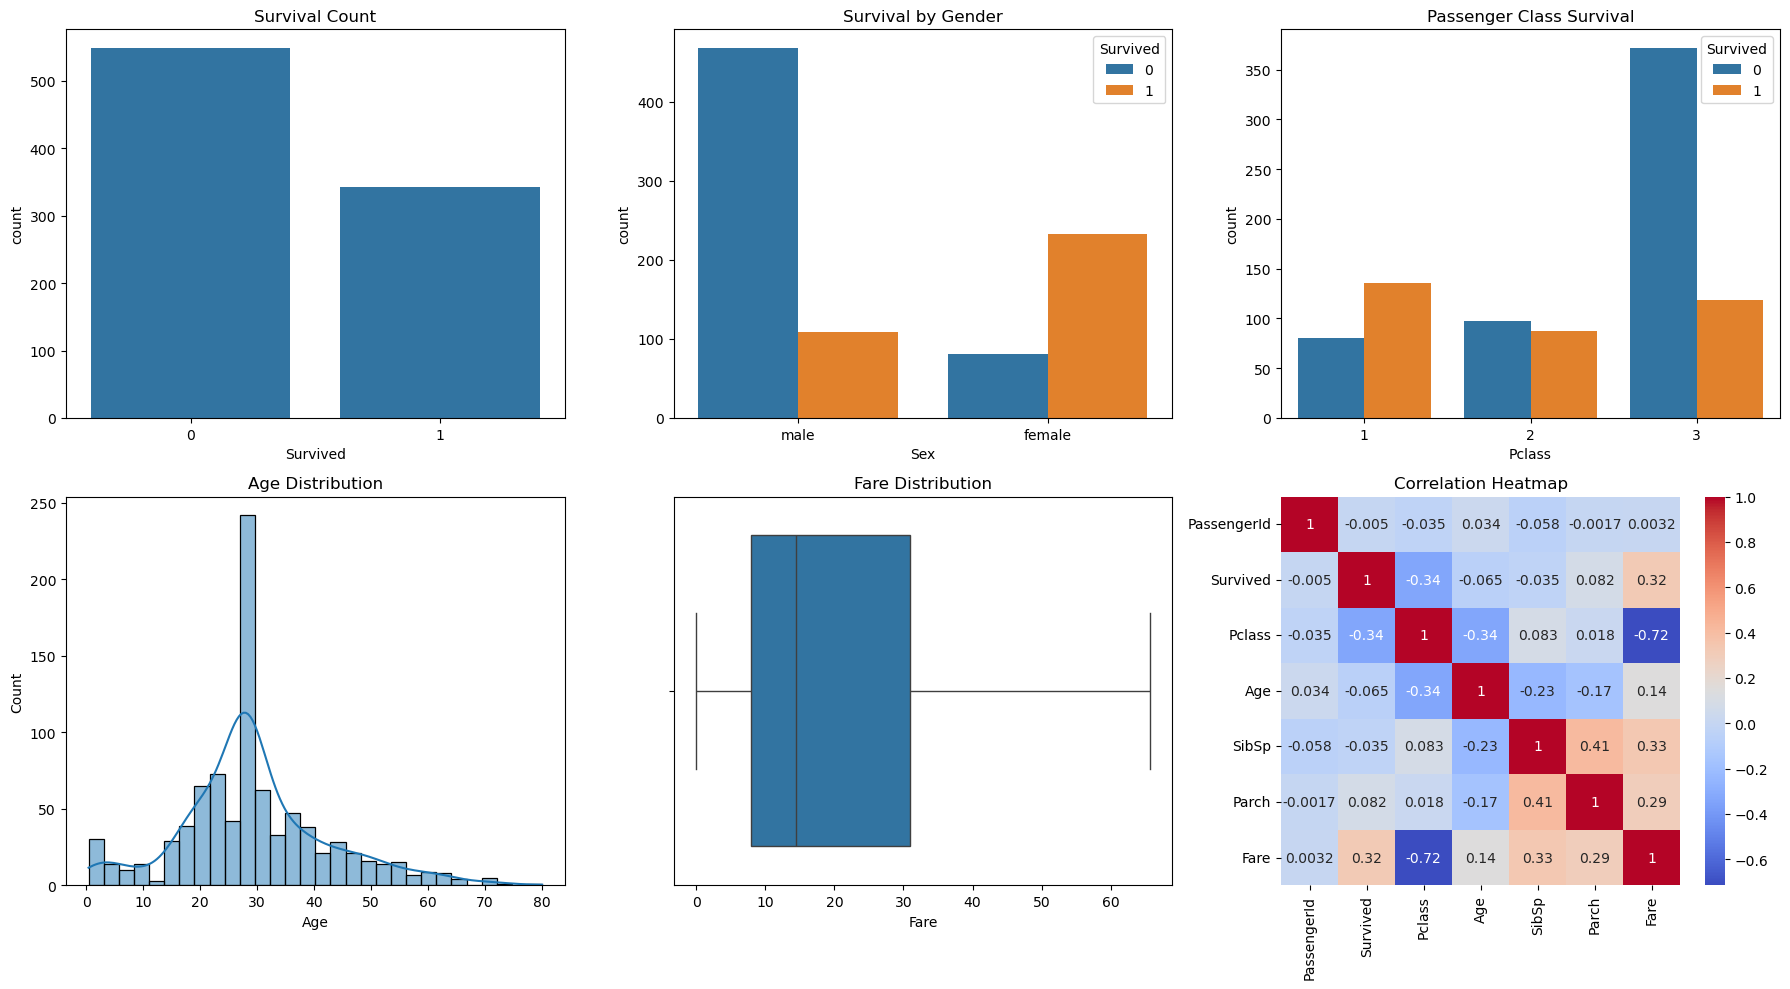

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# Survival Count
sns.countplot(x='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title('Survival Count')

# Gender Survival
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')

# Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0,2])
axes[0,2].set_title('Passenger Class Survival')

# Age Distribution
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title('Age Distribution')

# Fare Distribution
sns.boxplot(x=df['Fare'], ax=axes[1,1])
axes[1,1].set_title('Fare Distribution')

# Correlation Heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

Step 15: Key Insights

Example insights:

1. Female passengers had a higher survival rate.
2. First-class passengers survived more frequently.
3. Children had better survival chances.
4. Higher ticket fare is linked with better survival.
5. Most passengers were young adults.